In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from dataclasses import asdict
from functools import partial
from ciceroscm import input_handler
import pandas as pd
from meteor import MeteorPatternScaling
from meteor import prpatt
from meteor import Cmip6MeteorDataGetter
import warnings
from pandas.errors import SettingWithCopyWarning
warnings.filterwarnings('ignore', category=FutureWarning) 
warnings.simplefilter(action='ignore', category=(SettingWithCopyWarning))
warnings.filterwarnings("ignore", message=".*not in pamset.*")


In [2]:
import matplotlib.cm as cm

In [3]:
from meteor import prpatt

In [4]:
from scipy.linalg import pinv

In [5]:
cscm_data_dir = os.path.join(os.getcwd(), "..", "src", "meteor", "default_scm_data")


In [6]:
from meteor import scm_forcer_engine
from ciceroscm import CICEROSCM

Getting a datagetter to get CMIP6 data from the zarrstore for tas and pr

In [7]:
expts=["piControl", "abrupt-4xCO2", "historical","ssp585", "ssp245","ssp126"]
expts.index('historical')

2

In [8]:
flds = ["tas", "pr"]
data_getter = Cmip6MeteorDataGetter(exps=["piControl", "abrupt-4xCO2", "historical","ssp585", "ssp245","ssp126"], flds = flds, dbe=['CMIP','CMIP','CMIP', 'ScenarioMIP','ScenarioMIP','ScenarioMIP'])
# This list now holds all the models with complete data for a single ensemble member for the given experiments and fields
models = data_getter.models
# For the purposes of this notebook we limit the use to looking at two coarse resolution models:
models = ["CESM2"]

Getting some data that can be used by the forcer engine and ciceroscm

In [9]:
data_getter.models

['ACCESS-CM2',
 'ACCESS-ESM1-5',
 'AWI-CM-1-1-MR',
 'AWI-ESM-1-1-LR',
 'BCC-CSM2-MR',
 'BCC-ESM1',
 'CAMS-CSM1-0',
 'CAS-ESM2-0',
 'CESM2',
 'CESM2-FV2',
 'CESM2-WACCM',
 'CESM2-WACCM-FV2',
 'CIESM',
 'CMCC-CM2-SR5',
 'CMCC-ESM2',
 'CNRM-CM6-1',
 'CNRM-CM6-1-HR',
 'CNRM-ESM2-1',
 'CanESM5',
 'CanESM5-CanOE',
 'E3SM-1-0',
 'E3SM-1-1',
 'E3SM-1-1-ECA',
 'EC-Earth3',
 'EC-Earth3-AerChem',
 'EC-Earth3-CC',
 'EC-Earth3-LR',
 'EC-Earth3-Veg',
 'EC-Earth3-Veg-LR',
 'FGOALS-f3-L',
 'FGOALS-g3',
 'FIO-ESM-2-0',
 'GFDL-CM4',
 'GFDL-ESM4',
 'GISS-E2-1-G',
 'GISS-E2-1-G-CC',
 'GISS-E2-1-H',
 'GISS-E2-2-G',
 'GISS-E2-2-H',
 'HadGEM3-GC31-LL',
 'HadGEM3-GC31-MM',
 'ICON-ESM-LR',
 'IITM-ESM',
 'INM-CM4-8',
 'INM-CM5-0',
 'IPSL-CM5A2-INCA',
 'IPSL-CM6A-LR',
 'KACE-1-0-G',
 'KIOST-ESM',
 'MCM-UA-1-0',
 'MIROC-ES2H',
 'MIROC-ES2L',
 'MIROC6',
 'MPI-ESM-1-2-HAM',
 'MPI-ESM1-2-HR',
 'MPI-ESM1-2-LR',
 'MRI-ESM2-0',
 'NESM3',
 'NorCPM1',
 'NorESM1-F',
 'NorESM2-LM',
 'NorESM2-MM',
 'SAM0-UNICON',
 'TaiESM1'

In [10]:
%%capture
ih = input_handler.InputHandler({})
# NBVAL_IGNORE_OUTPUT

#For predictions: 
#read in SSP245 concentrations and emissions

scenarios = ["ssp119","ssp245","ssp585"]

conc_data=[]
em_data=[]
for i,s in enumerate(scenarios):
    conc_data.append(input_handler.read_inputfile(
    os.path.join(cscm_data_dir, s+"_conc_RCMIP.txt")
    ))

    em_data.append(ih.read_emissions(os.path.join(cscm_data_dir, s+"_em_RCMIP.txt")))

Getting training data to use for predictions:

In [11]:
training_data = {}
train_scenario = "ssp245"
for m in models:
    training_data[m] = {
            "base": data_getter.make_meteor_training_data("base", m), #control simulation
            "co2x4": data_getter.make_meteor_training_data("co2x4", m), #co2 only response
            "sulxanom": data_getter.make_meteor_training_data_composite(
                ["historical", train_scenario], m
            ), #concatenated historical and ssp245 
        }

86
86
range(165, 251)
86
86
range(165, 251)


In [13]:
training_data


{'CESM2': {'base': <xarray.Dataset> Size: 1GB
  Dimensions:  (ens: 1, lat: 192, lon: 288, year: 1200)
  Coordinates:
    * ens      (ens) int64 8B 1
    * lat      (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
    * lon      (lon) float64 2kB 0.0 1.25 2.5 3.75 5.0 ... 355.0 356.2 357.5 358.8
    * year     (year) int64 10kB 0 1 2 3 4 5 6 ... 1194 1195 1196 1197 1198 1199
  Data variables:
      tas      (ens, year, lat, lon) float64 531MB 224.4 224.4 ... 256.3 256.3
      pr       (ens, year, lat, lon) float64 531MB 2.315e-06 ... 6.33e-06,
  'co2x4': <xarray.Dataset> Size: 884MB
  Dimensions:  (ens: 1, lat: 192, lon: 288, year: 999)
  Coordinates:
    * ens      (ens) int64 8B 1
    * lat      (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
    * lon      (lon) float64 2kB 0.0 1.25 2.5 3.75 5.0 ... 355.0 356.2 357.5 358.8
    * year     (year) int64 8kB 0 1 2 3 4 5 6 7 ... 992 993 994 995 996 997 998
  Data variables:
      tas      (ens, year, lat

In [12]:
test_data={}
for m in models:
    test_data[m]['base']=training_data['base']
    test_data[m]['co2x4']=training_data['co2x4']
    for s in scenarios:
        test_data[m][s]=data_getter.make_meteor_training_data_composite(
                ["historical", s], m
            )


KeyError: 'base'

Making patterns one with just co2x4, and one including the sulfate from residual in the experiment. The fisrt will include just base (piControl) and co2x4 (abrupt4xCO2), the second will also have a sulxanom which we take from the historical and ssp245 composite experiment

First encode the pure CO2 response

In [ ]:
%%capture
canesm_ghg_pattern = MeteorPatternScaling(
        "cmip6-CanESM5-anomsulf",
        {"tas": 2, "pr": 2},
        lambda key: training_data[key],
        from_file=False,
        exp_list=["base", "co2x4"],
    )

Now encode a set of patterns, including the historical/future composite

In [ ]:
%%capture
canesm_anomsulf_pattern = MeteorPatternScaling(
        "cmip6-CanESM5-anomsulf",
        {"tas": 2, "pr": 2},
        lambda key: training_data[key],
        from_file=False,
        exp_list=["base", "co2x4", "sulxanom"],
    )

In [ ]:
canesm_anomsulf_pattern.exp_forc_dict

{'base': 0.0, 'co2x4': 8.534700743147258, 'sulxanom': 1.0}

Then taking the data from the ssp-data for ciceroscm and making predictions

In [ ]:
%%capture
patterns_ghg={}
patterns_anomsulf={}
for i,s in enumerate(scenarios):
    patterns_ghg[s]=(canesm_ghg_pattern.predict_from_combined_experiment(
        em_data[i], conc_data[i], ["pr", "tas"])
    )
    patterns_anomsulf[s]=(canesm_anomsulf_pattern.predict_from_combined_experiment(
        em_data[i], conc_data[i], ["pr", "tas"])
    )

Plotting global means for the CMIP6 data, the pattern with all forcing as CO2, and the pattern from including the aerosol residual as obtained above

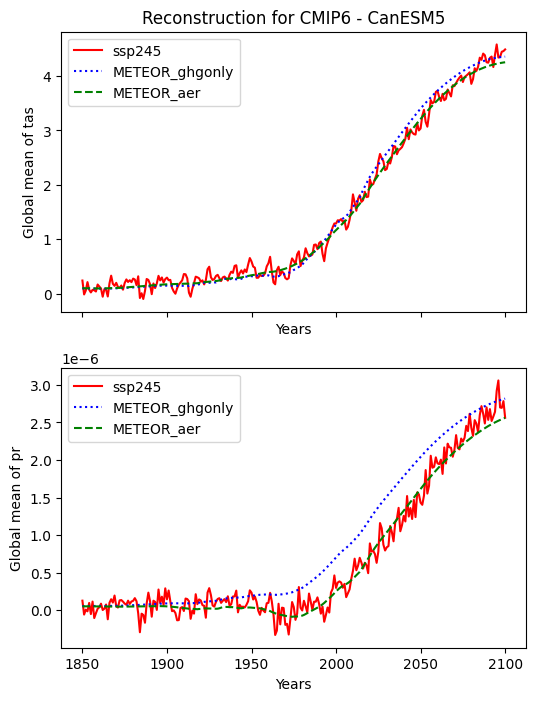

In [ ]:
# NBVAL_IGNORE_OUTPUT
fig, axs = plt.subplots(nrows=len(flds), ncols=1, sharex=True,figsize=(6,8))

for j, fld in enumerate(flds):
    zero_val = np.mean(prpatt.global_mean(training_data["base"][fld]).values)
    total_years = len(training_data["sulxanom"][fld]["year"].values)
    years_to_plot = range(1850,1850+total_years)
    axs[j].plot(years_to_plot, prpatt.global_mean(training_data["sulxanom"][fld]).values[0,:]-zero_val, color="red", label="ssp245")
    axs[j].plot(years_to_plot, prpatt.global_mean(patterns_ghg['ssp245'][fld]).values[100:], color="blue", label="METEOR_ghgonly",linestyle=':')
    axs[j].plot(years_to_plot, prpatt.global_mean(patterns_anomsulf['ssp245'][fld]).values[100:], color="green", label="METEOR_aer",linestyle='--')
    axs[j].set_xlabel("Years")
    if j == 0:
        axs[j].set_title(f"Reconstruction for CMIP6 - CanESM5")
    axs[j].set_ylabel(f"Global mean of {fld}")
    axs[j].legend()

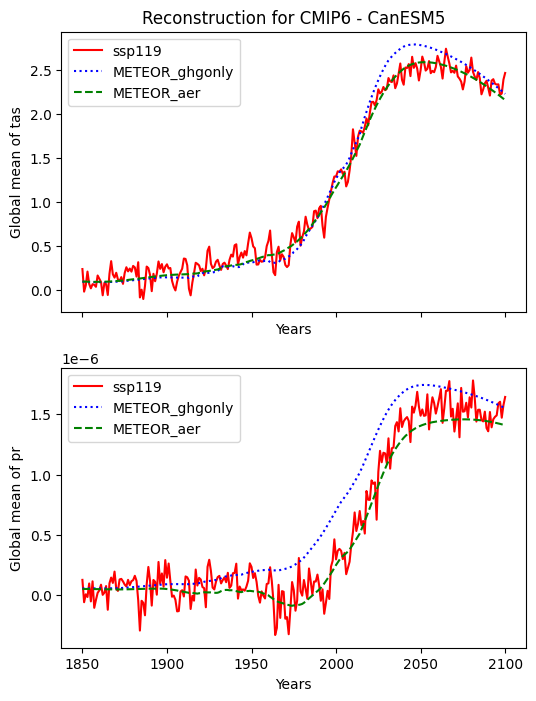

In [ ]:
# NBVAL_IGNORE_OUTPUT
fig, axs = plt.subplots(nrows=len(flds), ncols=1, sharex=True,figsize=(6,8))

for j, fld in enumerate(flds):
    zero_val = np.mean(prpatt.global_mean(training_data["base"][fld]).values)
    total_years = len(training_data["sulxanom"][fld]["year"].values)
    years_to_plot = range(1850,1850+total_years)
    axs[j].plot(years_to_plot, prpatt.global_mean(test_data["sulxanom"][fld]).values[0,:]-zero_val, color="red", label="ssp119")
    axs[j].plot(years_to_plot, prpatt.global_mean(patterns_ghg['ssp119'][fld]).values[100:], color="blue", label="METEOR_ghgonly",linestyle=':')
    axs[j].plot(years_to_plot, prpatt.global_mean(patterns_anomsulf['ssp119'][fld]).values[100:], color="green", label="METEOR_aer",linestyle='--')
    axs[j].set_xlabel("Years")
    if j == 0:
        axs[j].set_title(f"Reconstruction for CMIP6 - CanESM5")
    axs[j].set_ylabel(f"Global mean of {fld}")
    axs[j].legend()

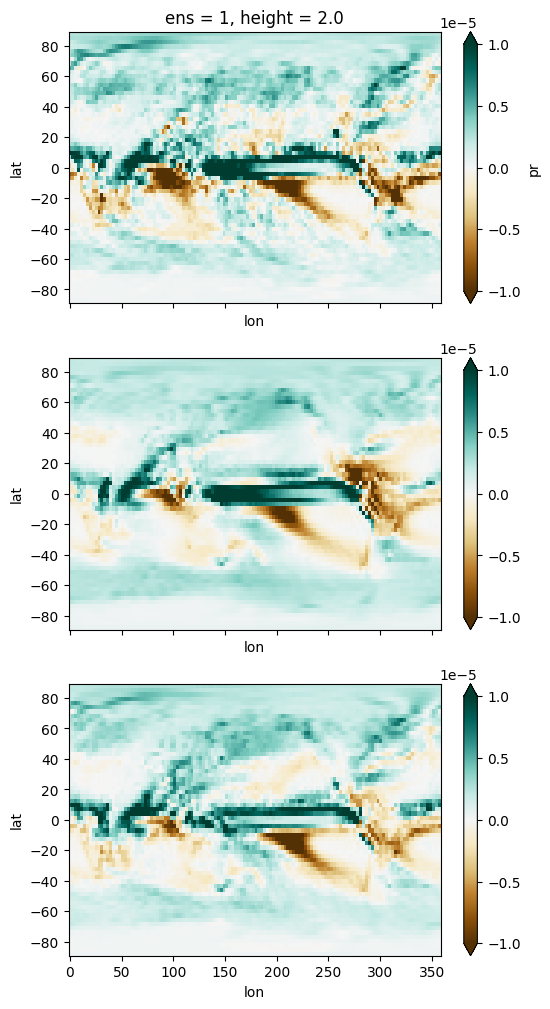

In [ ]:
fig, axs = plt.subplots(nrows=3, ncols=1, sharex=True,figsize=(6,12))
plt.set_cmap('bwr')
tmpw=(training_data["sulxanom"]['pr'][0,180:200,:,:].mean(dim='year')-(training_data["sulxanom"]['pr'][0,140:160,:,:]).mean(dim='year'))
tmpw.plot(ax=axs[0],cmap=cm.BrBG,vmin=-10e-6,vmax=10e-6)

tmpw=(patterns_ghg['pr'][280:300,:,:].mean(dim='time')-(patterns_ghg['pr'][240:260,:,:]).mean(dim='time'))
tmpw.plot(ax=axs[1],cmap=cm.BrBG,vmin=-10e-6,vmax=10e-6)

tmpw=(patterns_anomsulf['pr'][280:300,:,:].mean(dim='time')-(patterns_anomsulf['pr'][240:260,:,:]).mean(dim='time'))
tmpw.plot(ax=axs[2],cmap=cm.BrBG,vmin=-10e-6,vmax=10e-6)

In [ ]:
from global_land_mask import globe


In [ ]:
lat=tmpw.lat
lon=tmpw.lon
lon = np.where(lon > 180, lon-360, lon)

lon_grid, lat_grid = np.meshgrid(lon,lat)
is_in_ocean = globe.is_ocean(lat_grid, lon_grid)

In [ ]:
is_in_ocean

array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True]])

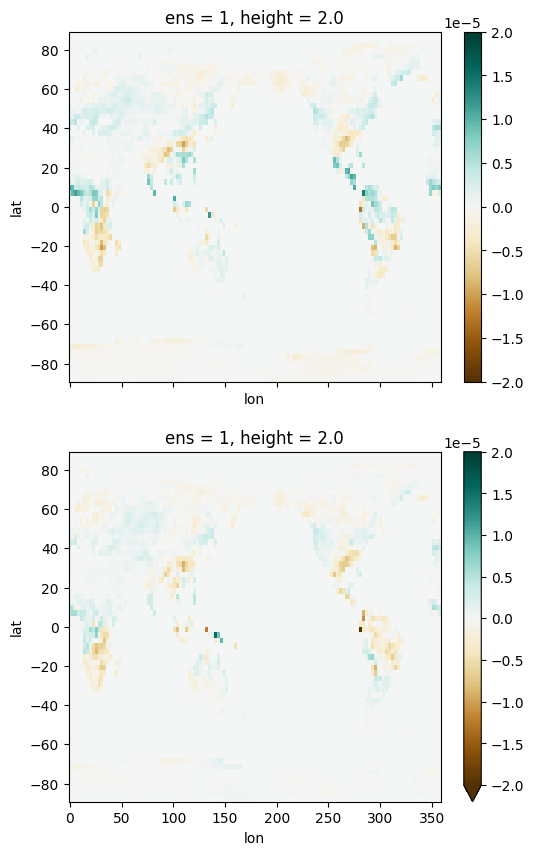

In [ ]:
fig, axs = plt.subplots(nrows=2, ncols=1, sharex=True,figsize=(6,10))
plt.set_cmap('bwr')
tmpw=(training_data["sulxanom"]['pr'][0,190:210,:,:].mean(dim='year')-(training_data["sulxanom"]['pr'][0,140:160,:,:]).mean(dim='year'))

tmpp=(patterns_ghg['pr'][290:310,:,:].mean(dim='time')-(patterns_ghg['pr'][240:260,:,:]).mean(dim='time'))
((tmpw-tmpp)*~is_in_ocean).plot(ax=axs[0],cmap=cm.BrBG,vmin=-20e-6,vmax=20e-6)

tmpp2=(patterns_anomsulf['pr'][290:310,:,:].mean(dim='time')-(patterns_anomsulf['pr'][240:260,:,:]).mean(dim='time'))
((tmpw-tmpp2)*~is_in_ocean).plot(ax=axs[1],cmap=cm.BrBG,vmin=-20e-6,vmax=20e-6)

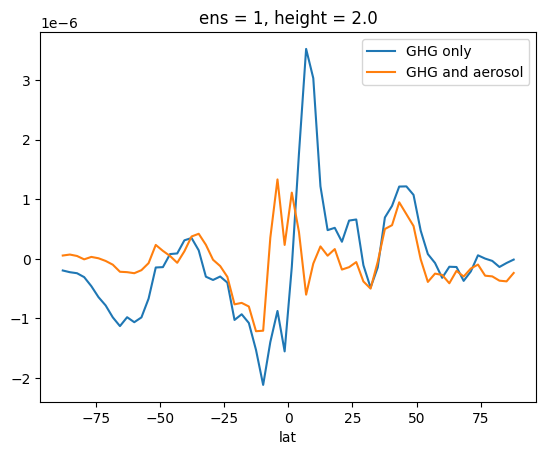

In [ ]:
(tmpw-tmpp).mean('lon').plot(label='GHG only')
(tmpw-tmpp2).mean('lon').plot(label='GHG and aerosol')
plt.legend()

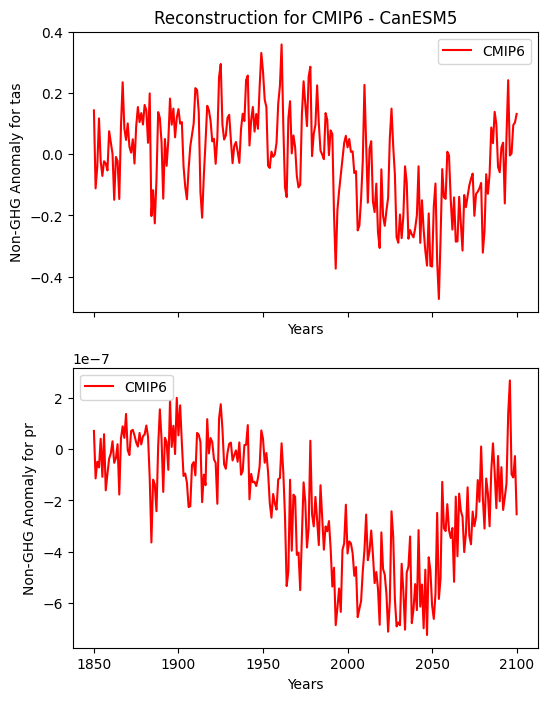

In [ ]:
# NBVAL_IGNORE_OUTPUT
fig, axs = plt.subplots(nrows=len(flds), ncols=1, sharex=True,figsize=(6,8))

for j, fld in enumerate(flds):
    zero_val = np.mean(prpatt.global_mean(training_data["base"][fld]).values)
    total_years = len(training_data["sulxanom"][fld]["year"].values)
    years_to_plot = range(1850,1850+total_years)
    axs[j].plot(years_to_plot, prpatt.global_mean(training_data["sulxanom"][fld]).values[0,:]-zero_val- prpatt.global_mean(patterns_ghg[fld]).values[100:], color="red", label="CMIP6")
   # axs[j].plot(years_to_plot, prpatt.global_mean(patterns_ghg[fld]).values[100:], color="blue", label="METEOR_ghgonly",linestyle=':')
    #axs[j].plot(years_to_plot, prpatt.global_mean(patterns_anomsulf[fld]).values[100:], color="green", label="METEOR_aer",linestyle='--')
    axs[j].set_xlabel("Years")
    if j == 0:
        axs[j].set_title(f"Reconstruction for CMIP6 - CanESM5")
    axs[j].set_ylabel(f"Non-GHG Anomaly for {fld}")
    axs[j].legend()

In [ ]:
patterns_ghg[fld]

<xarray.DataArray (time: 351, lat: 64, lon: 128)> Size: 23MB
array([[[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        ...,
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00]],

       [[2.37984739e-11, 2.34016028e-11, 2.28088594e-11, ...,
         2.53516528e-11, 2.49509013e-11, 2.45368822e-11],
        [1.91681308e-11, 1.83135732e-11, 1.75165752e-11, ...,
         2.09852130e-11, 2.06123101e-11, 2.00598553e-11],
        [1.56561864e-11, 1.54016530e-11, 1.51559523e-11, ...,
         1.87941777e-11, 1.73798199e-11, 1.64339525e-11],
...
        [5.24477065e-06, 5.28361140e-06, 5.14267475e-06, ...,
         4.82888910e-06, 4.92994648e-06, 5.10636376e-06],
        [5.09425538e-06, 5.11066563e-06, 5.05389900e-06, ...,
         4.95367756e-06, 4.98294603e-06, 5.03651919e-06],
        [4.94590982e-06, 4.93283987e-06, 4.92226193e-06, ...,
         5.03600651e-06, 5.02448577e-06, 4.97155501e-06]],

       [[1.29542320e-06, 1.29348261e-06, 1.28666134e-06, ...,
         1.29590114e-06, 1.29282007e-06, 1.29256261e-06],
        [9.71475269e-07, 9.51337692e-07, 9.26541919e-07, ...,
         1.04668308e-06, 1.02798616e-06, 9.97337996e-07],
        [1.02131495e-06, 9.84873696e-07, 9.41865207e-07, ...,
         1.10443712e-06, 1.06753343e-06, 1.03890790e-06],
        ...,
        [5.25359878e-06, 5.29178352e-06, 5.14866139e-06, ...,
         4.83387207e-06, 4.93697559e-06, 5.11413640e-06],
        [5.09668697e-06, 5.11389379e-06, 5.05672826e-06, ...,
         4.95364497e-06, 4.98343885e-06, 5.03723743e-06],
        [4.94796106e-06, 4.93548966e-06, 4.92536609e-06, ...,
         5.03722778e-06, 5.02633292e-06, 4.97319718e-06]]])
Coordinates:
  * lat      (lat) float64 512B -87.86 -85.1 -82.31 -79.53 ... 82.31 85.1 87.86
  * lon      (lon) float64 1kB 0.0 2.812 5.625 8.438 ... 348.8 351.6 354.4 357.2
  * time     (time) datetime64[ns] 3kB 1750-01-01 1751-01-01 ... 2100-01-01

In [ ]:
canesm_anomsulf_pattern.